<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/7.0%20Final_Delivery%3A%20Churn%20and%20CLTV%20Inference%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
#!pip install s3fs

### 1.0 INTRODUCTION
Having trained and validated `Segmentation`, `Churn`, and `CLTV` predictive models on data before `2011-08-31`, this notebook serves as the inference backend, making prediction on customer data without known outcomes, currently data after `2011-08-31`.

#### 1.1 Extract, Load and Transform (ETL) Pipeline
- The `data engineering notebook` receives unclean data as it would would be captured during data entry, stored in AWS S3 datalake as an excel file, loads it into a dataframe, upon which a data cleaning function created in the `data engineering` notebook is applied, and once cleaned, loaded into a `Postrges Database` table, and a copy uploaded as a parquet file back to AWS datalake.

#### 1.2 Inference Pipeline
- The clean data from the SQL table, is imported and loaded into a dataframe in this notebook, a feature engineering function is applied to clients that currently have a 60-day tenure, and the customer specific features loaded into a separate SQL table in the postgres database.
- The joblib files holding the segmentation, churn, and cltv predictive models, are streamed and loaded into memory. Thereafter, the customer features table is exported from Postgres SQL database, the customer segments are extracted and merged to each clients features. Each customers churn status and probability in the next 100 days is predicted, and thereafter, their expected 100-day spend, `if they don't churn`, is also predicted. Once all prediction have been made, they are loaded into a seperate SQL table.

Preview of data streamed from AWS S3 before feature engineering:

In [116]:
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-08-31'

df = pd.read_parquet(parquet_url)


df = df[df["InvoiceDate"].dt.date.astype('str') > cutoff_date].reset_index(drop = True)
df.info()
print("\nPreview of data exported from AWS S3 datalake")
print()
df.sort_values("InvoiceDate").head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170792 entries, 0 to 170791
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    170792 non-null  object        
 1   StockCode    170792 non-null  object        
 2   Description  170792 non-null  object        
 3   Quantity     170792 non-null  int64         
 4   InvoiceDate  170792 non-null  datetime64[ns]
 5   UnitPrice    170792 non-null  float64       
 6   CustomerID   170792 non-null  float64       
 7   Country      170792 non-null  object        
 8   Revenue      170792 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 11.7+ MB

Preview of data exported from AWS S3 datalake



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,565080,20677,PINK POLKADOT BOWL,8,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,10.0
1,565080,22128,PARTY CONES CANDY ASSORTED,24,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,30.0
2,565082,22423,REGENCY CAKESTAND 3 TIER,2,2011-09-01 09:15:00,12.75,13305.0,United Kingdom,25.5
3,565082,15060B,FAIRY CAKE DESIGN UMBRELLA,8,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,30.0
4,565082,23245,SET OF 3 REGENCY CAKE TINS,4,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,19.8


### 2.0 FEATURE ENGINEERING

This section extracts features from raw transaction, for the first 60-days of every clients spend after `2011-08-31`, that hit the predefined tenure mark by `2011-12-09`.

In [117]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days

df = df.merge(data, on = "CustomerID", how = "left")

X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()

X_features.drop(["FirstPurchase", "Cutoff"], axis = 1, inplace = True)

X_features = feature_engineering(X_features)

#Filtering Segmentation to Ensure Each client had the chance to shop with in exactly 60 from first purchase
X_features = X_features[X_features['Tenure'] >= 60]

features = X_features.fillna(0)

df1 = features

df1.info()
print()
df1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1579 entries, 1 to 2966
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   CustomerID               1579 non-null   float64  
 1   Frequency                1579 non-null   int64    
 2   ProductDiversity         1579 non-null   int64    
 3   AvgUnitPrice             1579 non-null   float64  
 4   AvgQuantity              1579 non-null   float64  
 5   AOV                      1579 non-null   float64  
 6   TotalRevenue             1579 non-null   float64  
 7   CohortMonth              1579 non-null   period[M]
 8   Recency                  1579 non-null   int64    
 9   Tenure                   1579 non-null   int64    
 10  ObservedLifeSpan         1579 non-null   int64    
 11  RecencyToTenure          1579 non-null   float64  
 12  ActivePurchaseDensity    1579 non-null   float64  
 13  LifetimePurchaseDensity  1579 non-null   float64  
 1

,CustomerID,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,CohortMonth,Recency,Tenure,ObservedLifeSpan,RecencyToTenure,ActivePurchaseDensity,LifetimePurchaseDensity,ActiveMRate,LifetimeMRate,AvgIPI,RelativeSilence
1,12348.0,1,2,1.250000,108.000000,135.000000,270.00,2011-09,75,75,1,1.000000,1.000000,0.013333,270.000000,3.600000,1.000000,75.000000
3,12352.0,3,38,4.341591,6.295455,16.914318,744.23,2011-09,36,80,45,0.450000,0.066667,0.037500,16.538444,9.302875,15.333333,2.347826
9,12362.0,5,113,4.425159,7.952381,21.268571,2679.84,2011-09,36,73,37,0.493151,0.135135,0.068493,72.428108,36.710137,7.800000,4.615385
10,12364.0,2,22,1.304091,20.272727,15.175455,333.86,2011-09,40,78,38,0.512821,0.052632,0.025641,8.785789,4.280256,19.500000,2.051282
13,12371.0,1,62,3.291613,9.387097,24.644516,1527.96,2011-10,60,60,1,1.000000,1.000000,0.016667,1527.960000,25.466000,1.000000,60.000000


### 3.0 Customer Segment Assignment, and Churn and CLTV predictions
In this section, the KMeans Clustering, Churn, and CLTV trained models are import from AWS S3.

In [118]:
# loading models into memory from data

kmeans = "s3://sales-data-analytics-portfolio-2026/predictive_models/kmeans_segmentation_60.joblib"
churn = "s3://sales-data-analytics-portfolio-2026/predictive_models/churn_model.joblib"
cltv = "s3://sales-data-analytics-portfolio-2026/predictive_models/cltv_model.joblib"

with fs.open(kmeans, "rb") as f:
    loaded_kmeans_model = joblib.load(f)

with fs.open(churn, "rb") as f:
    loaded_churn_model = joblib.load(f)

with fs.open(cltv, "rb") as f:
    loaded_cltv_model = joblib.load(f)

# Features to drop from features dataframe by model
segmentation_features = ["CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
churn_features = ["TotalRevenue","Churned", "KSegment","CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
cltv_features = ['ActiveMRate','TotalRevenue','RevenueTarget','KSegment','AOVTarget','FrequencyTarget', 'RevenueTarget', 'CustomerID', 'CohortMonth', 'Tenure', 'Recency', 'RecencyToTenure', 'LifetimePurchaseDensity', 'LifetimeMRate', 'RelativeSilence']

In [119]:
# Assigning Kmeans labels
kmeans_labels = loaded_kmeans_model.predict(df1[loaded_kmeans_model.feature_names_in_])

df2 = df1.copy()
df2["KSegment"] = kmeans_labels

persona_map = {
    2: "One-Time Acquaintance",
    1: "Loyal Performer",
    3: "High-Value Elite",
    0: "One-Time Bulk-Buyer"
}

df2["Persona"] = df2["KSegment"].map(persona_map)

# Predicting churn label and probabilities
X_churn = pd.get_dummies(df2, drop_first = True)
X_churn = X_churn[loaded_churn_model.feature_names_in_]


churn_label = loaded_churn_model.predict(X_churn)
churn_proba = loaded_churn_model.predict_proba(X_churn)[:,1]

df3 = df2.copy()
df3["ChurnLabel"] = churn_label
df3["ChurnProbability"] = churn_proba

# Predicting 100-days customer lifetime value
X_cltv = pd.get_dummies(df2, drop_first = True)
X_cltv = X_churn[loaded_cltv_model.feature_names_in_]

cltv_100 = loaded_cltv_model.predict(X_cltv)
df3["PredictedCLTV"] = cltv_100

# Filtering dataframe for customers expected to churn
churned_df = df3.query('ChurnLabel == 1').copy()

churned_df[["CustomerID", "Persona", "ChurnProbability", "ChurnLabel", "PredictedCLTV"]].head()

,CustomerID,Persona,ChurnProbability,ChurnLabel,PredictedCLTV
13,12371.0,One-Time Acquaintance,0.595569,1,970.629566
14,12372.0,One-Time Acquaintance,0.689122,1,382.152134
16,12375.0,One-Time Acquaintance,0.722733,1,321.938432
17,12379.0,One-Time Acquaintance,0.696200,1,431.383079
21,12388.0,One-Time Acquaintance,0.644440,1,704.262673


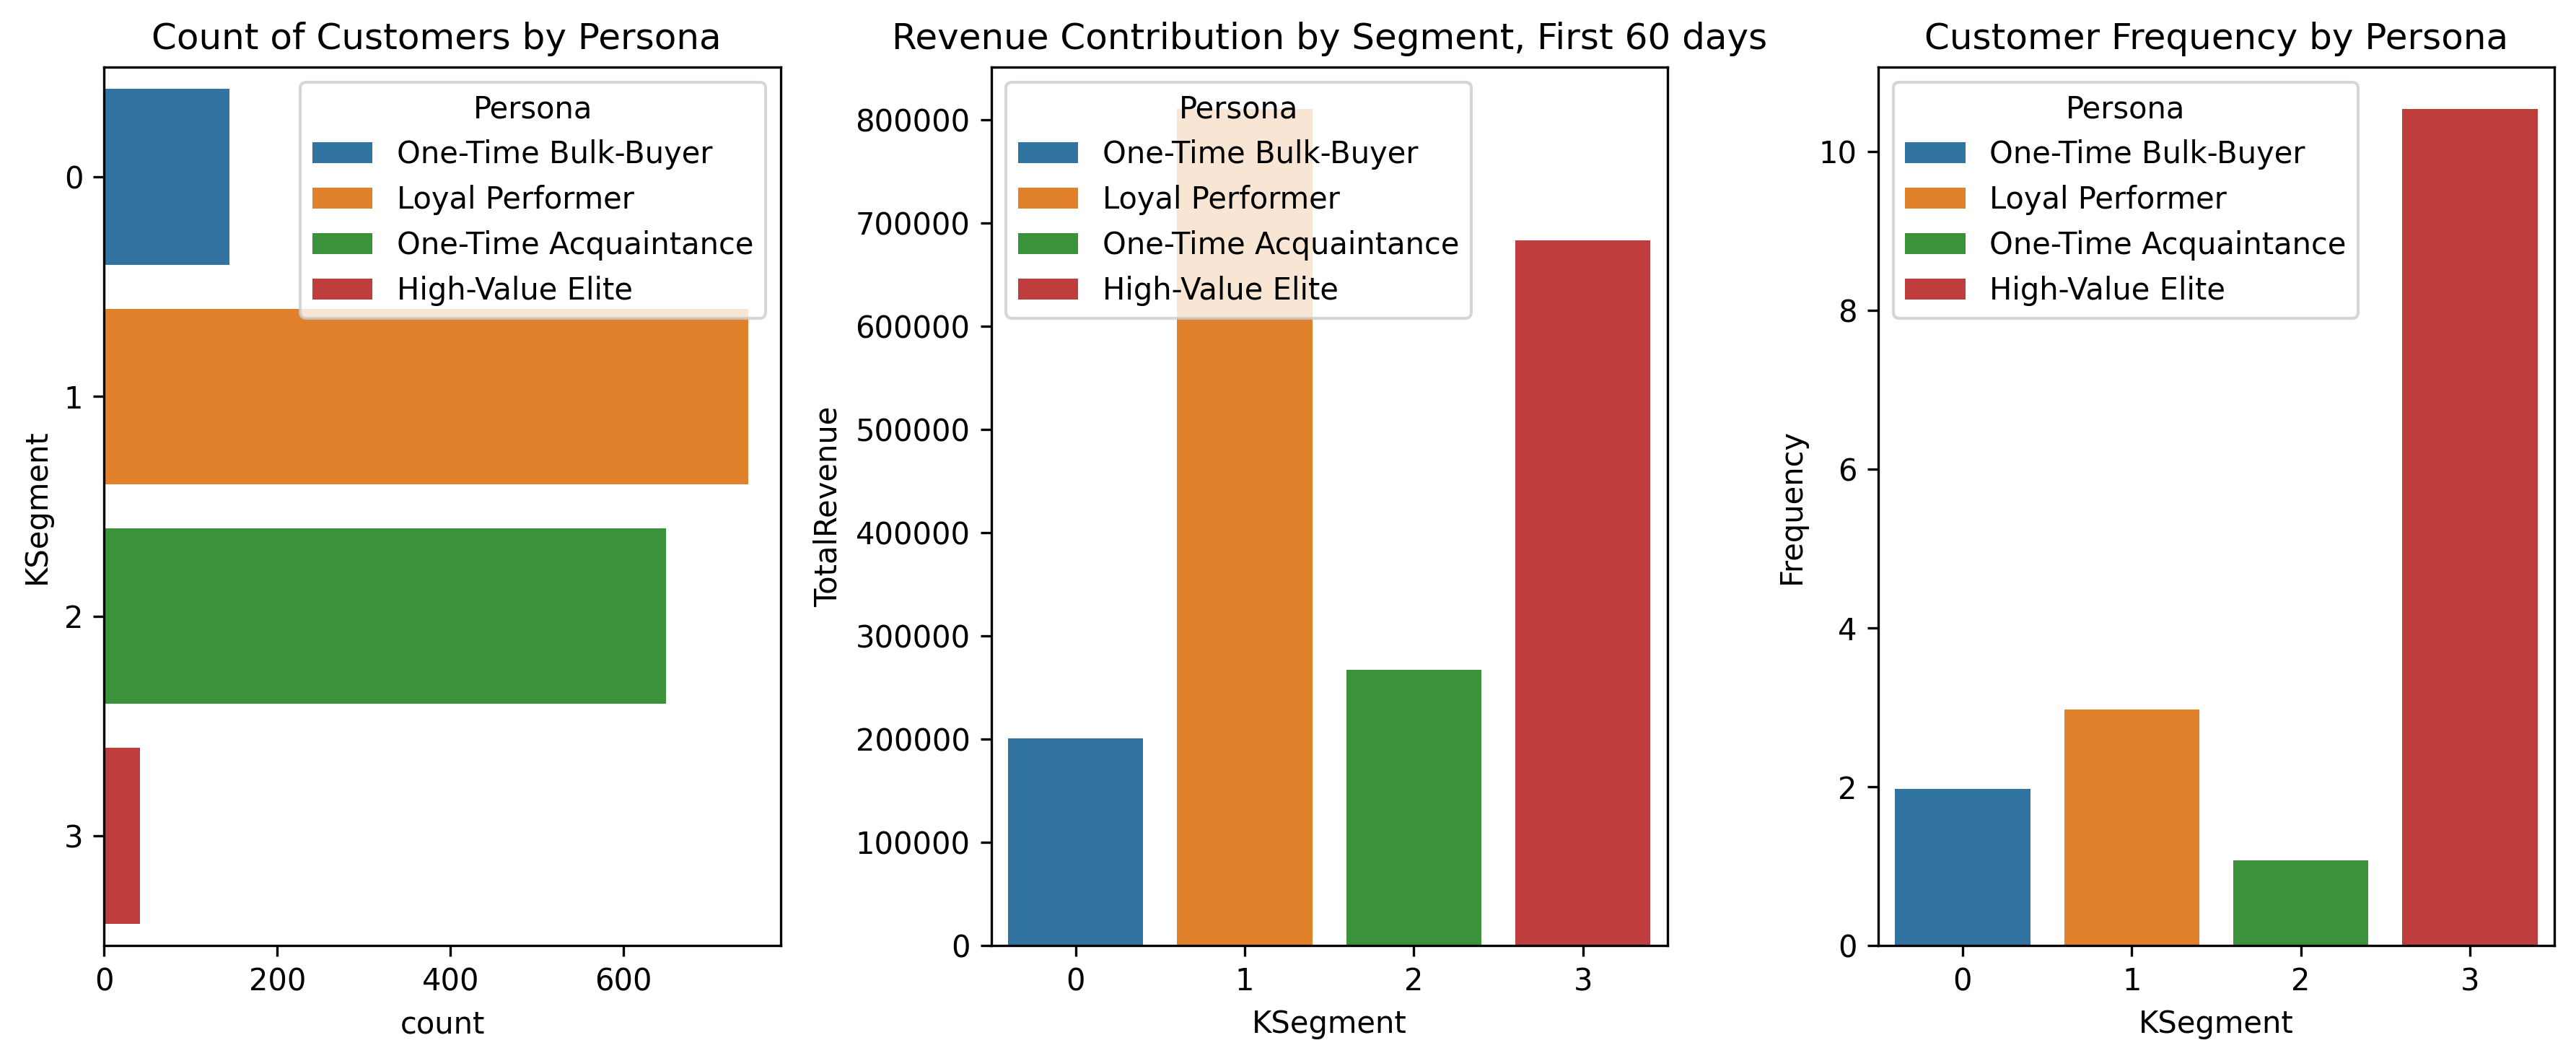

In [120]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.barplot(data = df3, x = "KSegment", y = "Frequency", errorbar = None, hue = "Persona", ax = ax3)
ax3.set_title("Customer Frequency by Persona")

sns.barplot(data = df3, x = "KSegment", y = "TotalRevenue", estimator = 'sum', errorbar = None, hue = "Persona", ax = ax2)
ax2.set_title("Revenue Contribution by Segment, First 60 days")

sns.countplot(data = df3, y = "KSegment", hue = "Persona", ax = ax1)
ax1.set_title("Count of Customers by Persona ")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

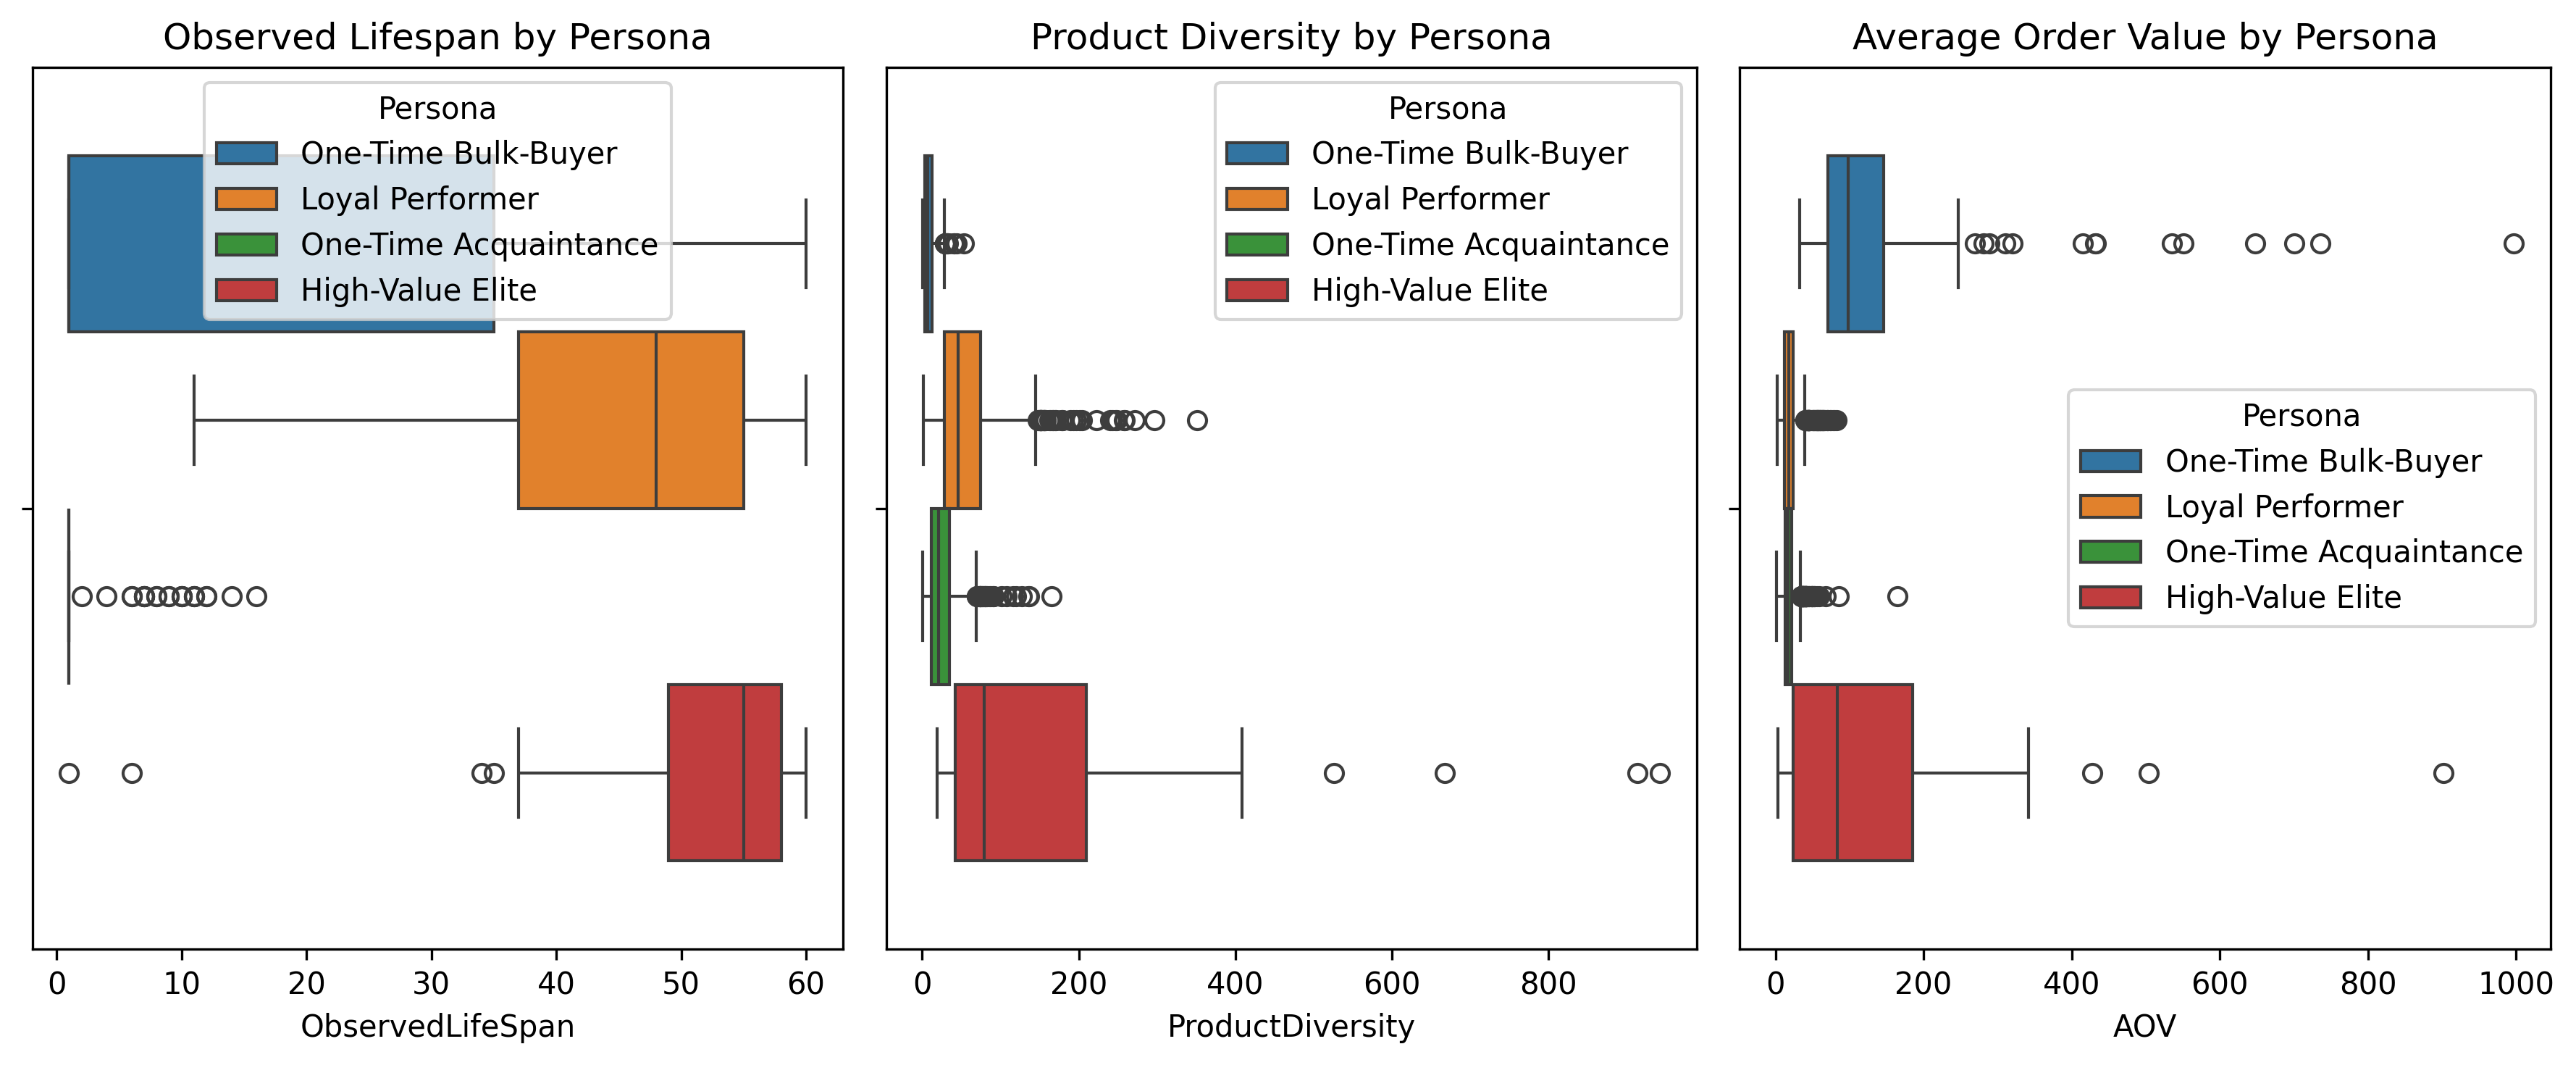

In [121]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.boxplot(data = df3, x = "AOV", hue = "Persona", ax = ax3)
ax3.set_title("Average Order Value by Persona")

sns.boxplot(data = df3, x = "ProductDiversity", hue = "Persona", ax = ax2)
ax2.set_title("Product Diversity by Persona")

sns.boxplot(data = df3, x = "ObservedLifeSpan", hue = "Persona", ax = ax1)
ax1.set_title("Observed Lifespan by Persona")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

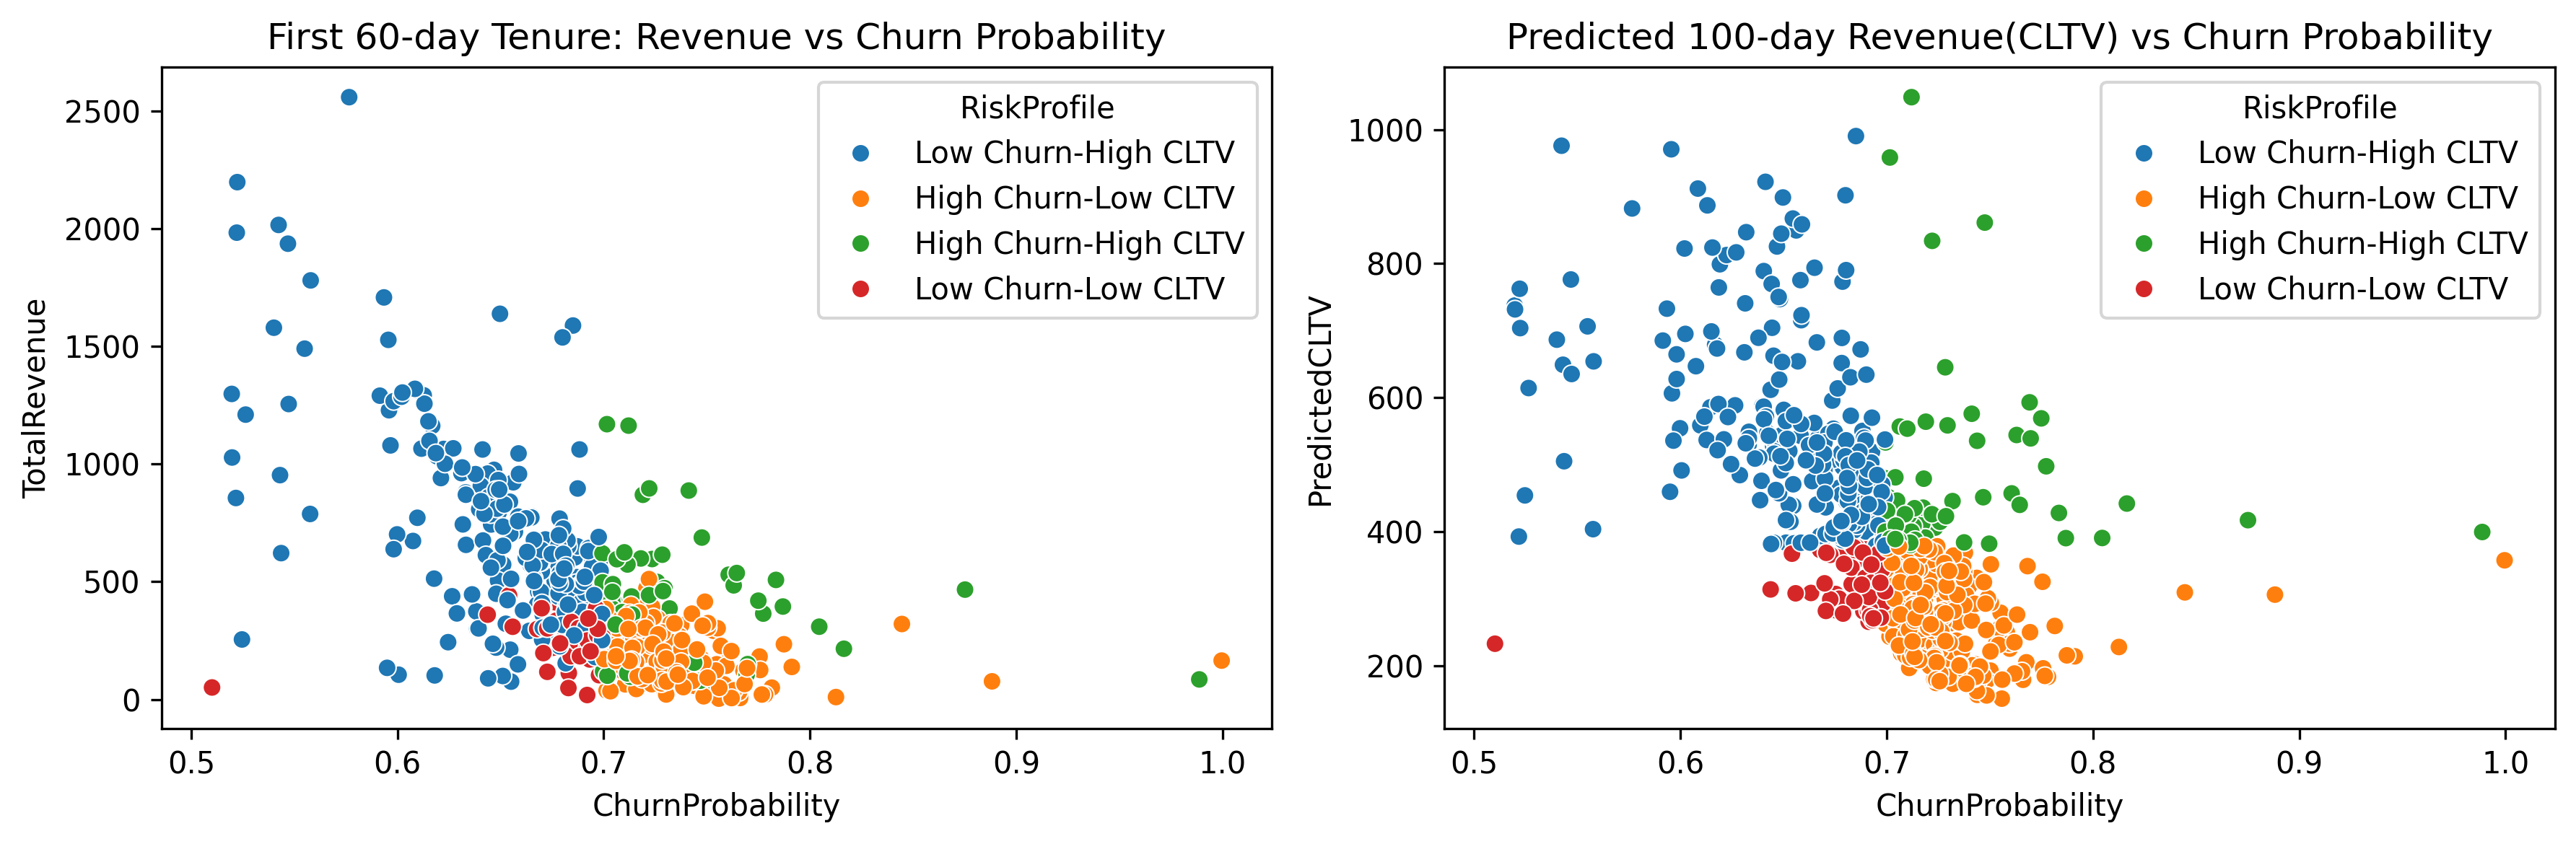

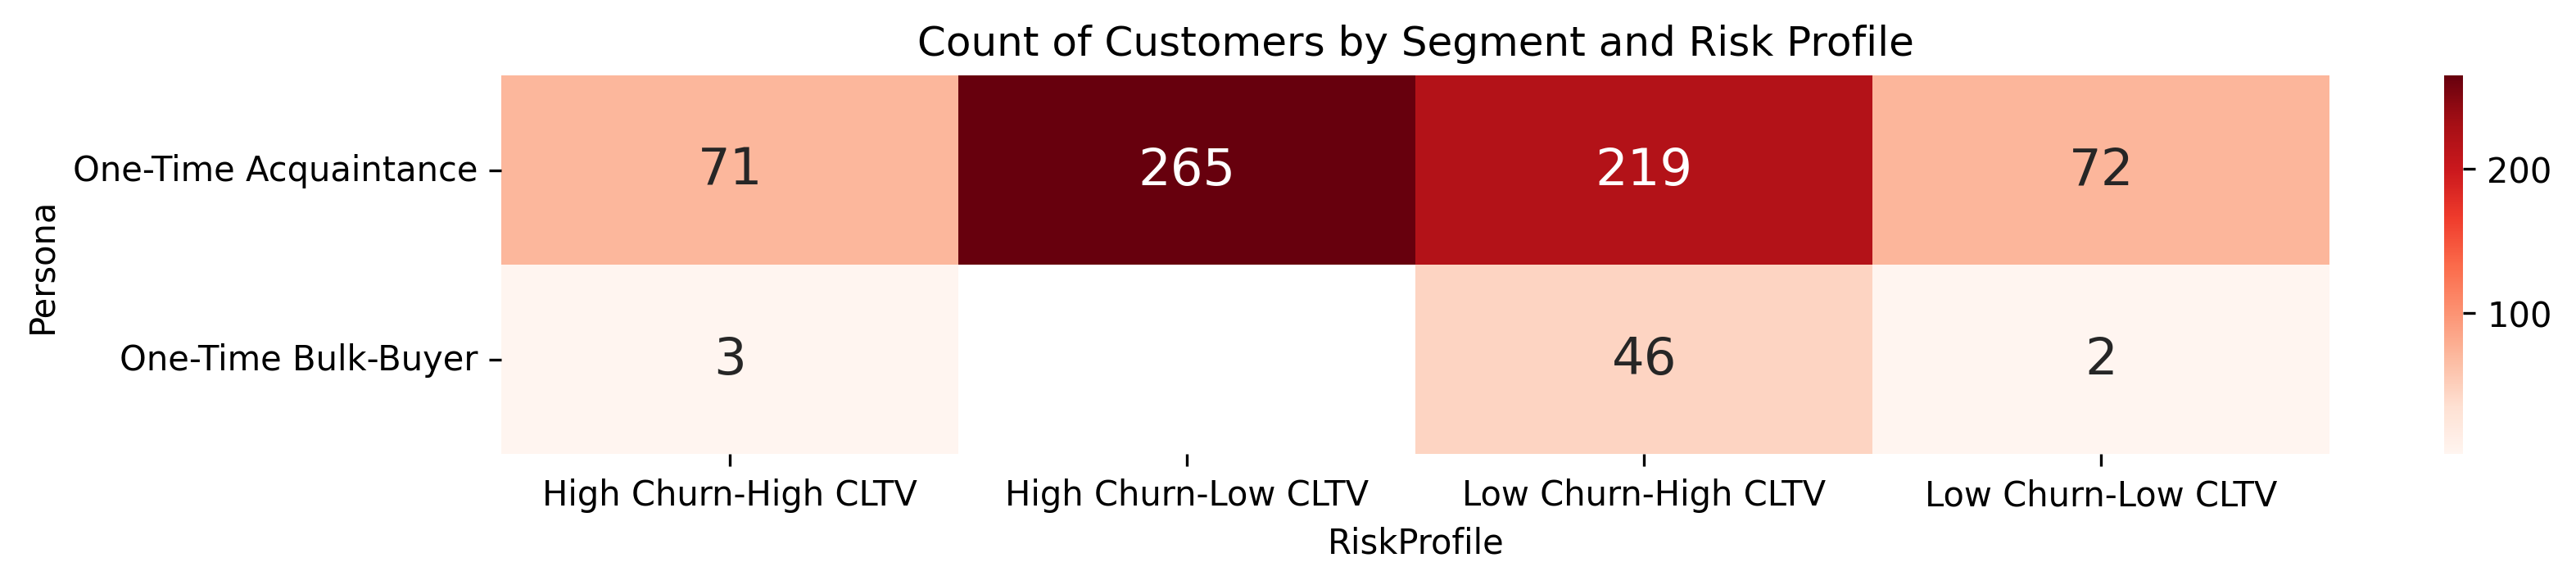

In [133]:
churned_df["ChurnClass"] = pd.qcut(churned_df["ChurnProbability"], q = 2, labels = ["Low Churn", "High Churn"])
churned_df["CLTVClass"] = pd.qcut(churned_df["PredictedCLTV"], q = 2, labels = ["Low CLTV", "High CLTV"])
churned_df["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")
df3["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)
sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'TotalRevenue', hue = 'RiskProfile', ax = ax1)
ax1.set_title('First 60-day Tenure: Revenue vs Churn Probability')

sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'PredictedCLTV', hue = 'RiskProfile', ax = ax2)
ax2.set_title('Predicted 100-day Revenue(CLTV) vs Churn Probability')
plt.tight_layout()
plt.show()

summary = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'CustomerID', aggfunc = 'count')

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Count of Customers by Segment and Risk Profile')
plt.show()



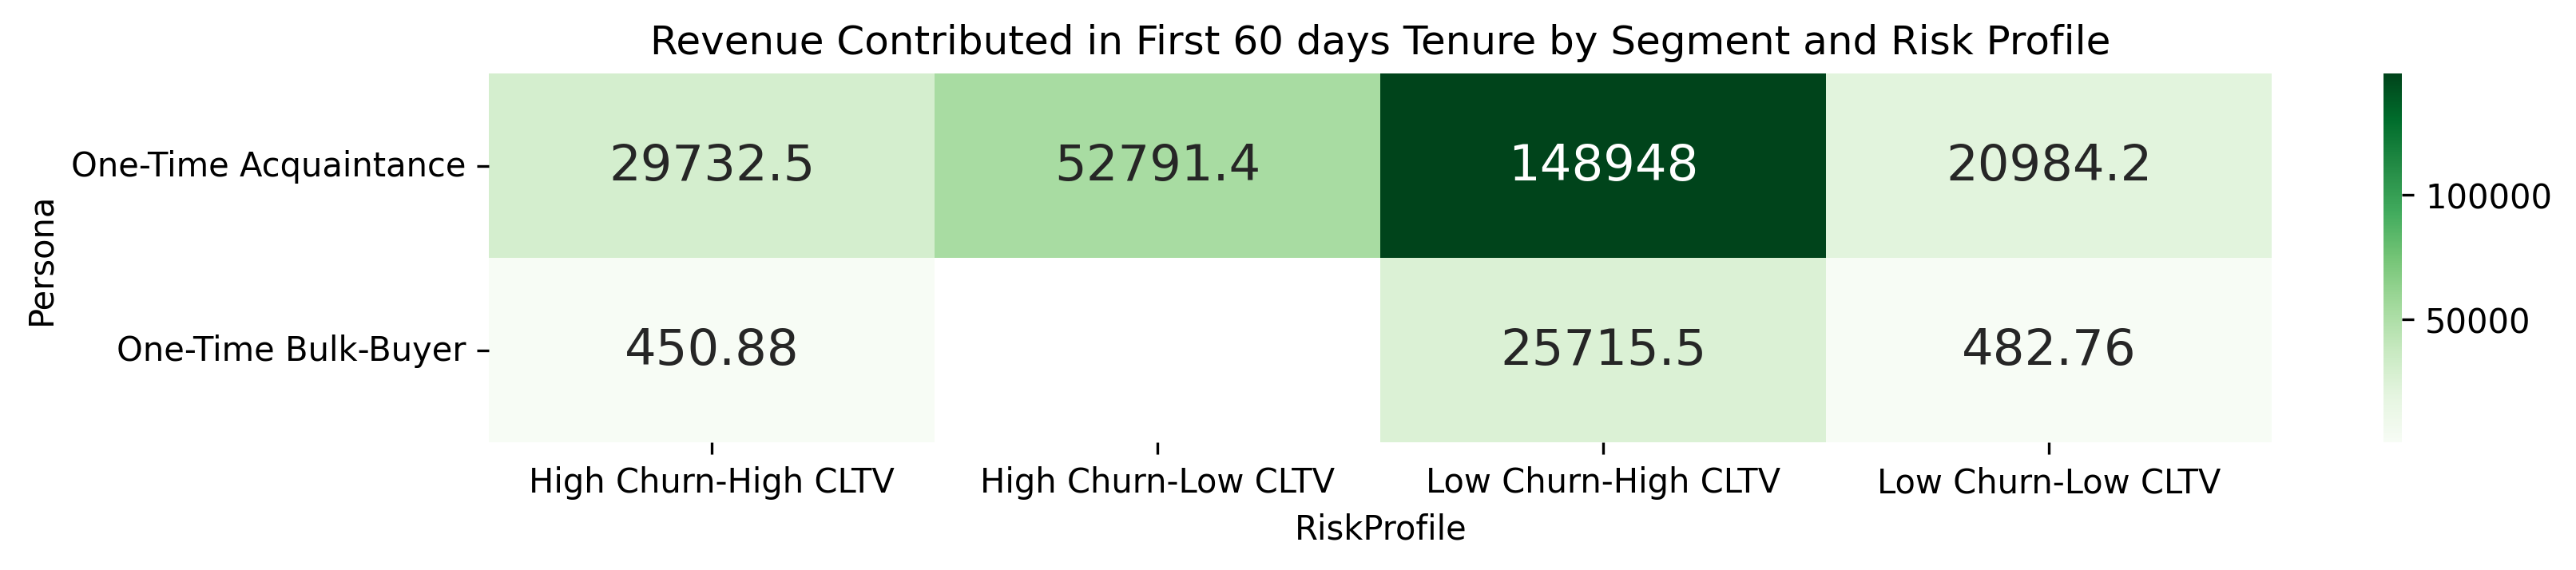

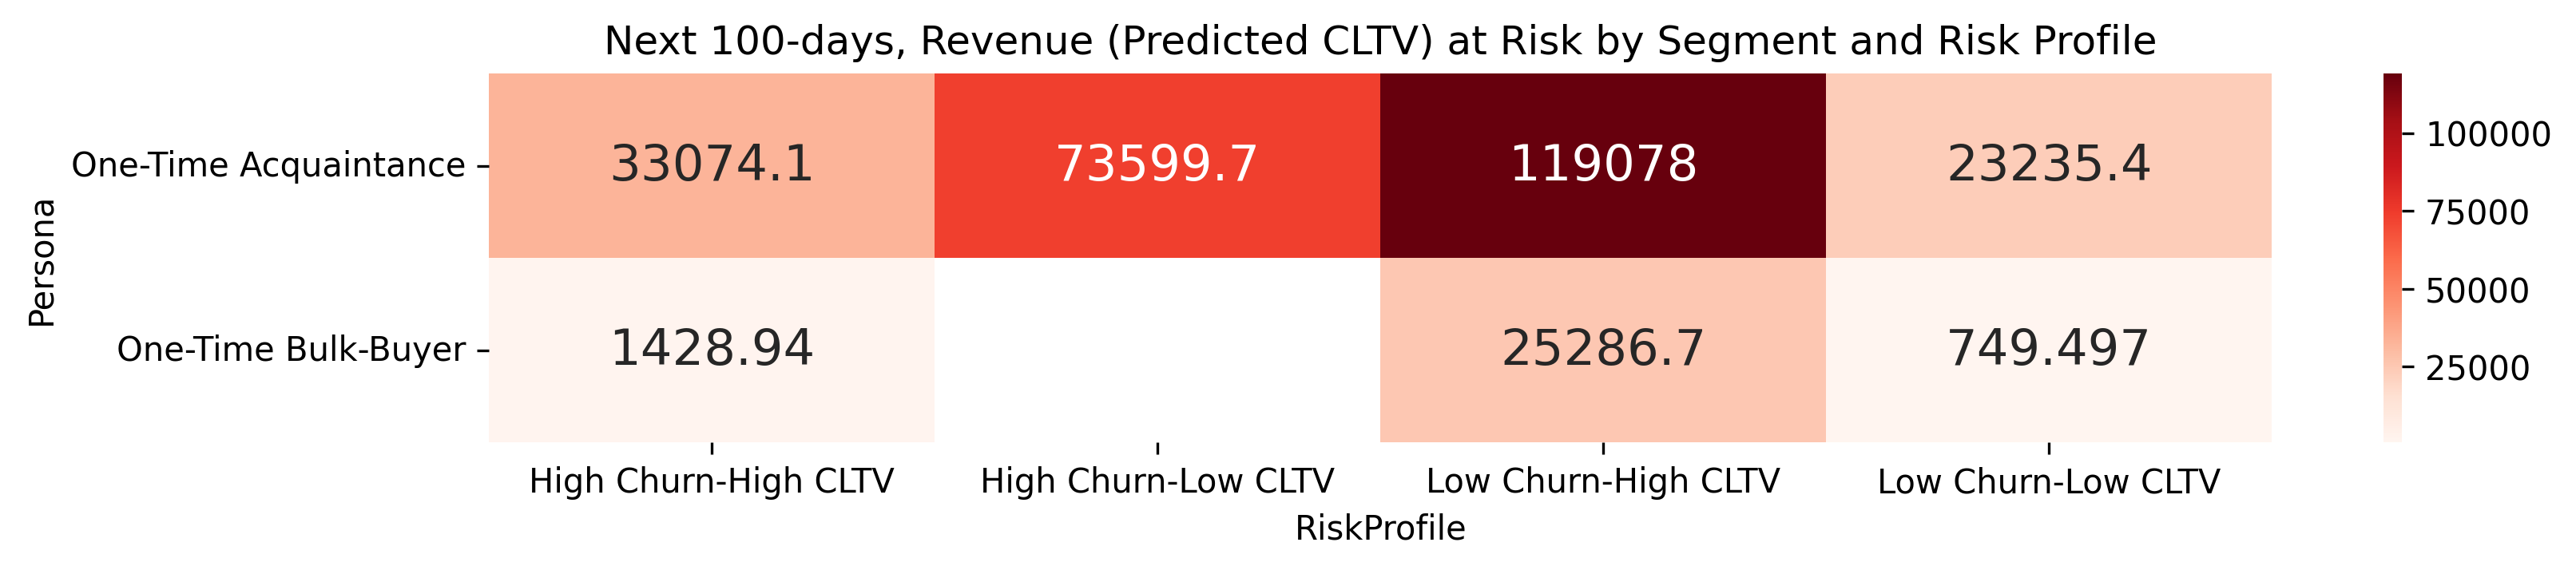

In [126]:
summary1 = df3.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'TotalRevenue', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Greens')
plt.title('Revenue Contributed in First 60 days Tenure by Segment and Risk Profile')
plt.show()

summary1 = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'PredictedCLTV', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Next 100-days, Revenue (Predicted CLTV) at Risk by Segment and Risk Profile')
plt.show()
